# **hw01**
---
To account for potential version issues, try the following in your terminal:

1. Create a new environment with `python3 -m venv venv`
2. Activate that environment with `source venv/bin/activate`
3. Make sure the interpreter in the top right corner of your VSCode (or whatever you use to run your code is venv).
4. If you get a "install kernel" message, press it.
5. Run `pip install -r requirements.txt`
6. Run the remainder of this notebook.

Note that this is not necessary but can help prevent any issues due to package versions.

**The following notebook is meant to help you work through Problems 1, 3, and 4 on Homework 1. You are by no means required to use it, nor are you required to fill out/use any of the boilerplate code/functions. You are welcome to implement the functions however you wish.**

In [2]:
# Loading data
import numpy as np
import matplotlib.pyplot as plt

train_data = np.genfromtxt("data/earth_temperature_sampled_train.csv", delimiter = ',')
year_train = train_data[:, 0] / 1000
temp_train = train_data[:, 1]
test_data = np.genfromtxt("data/earth_temperature_sampled_test.csv", delimiter = ',')
year_test = test_data[:, 0] / 1000
temp_test = test_data[:, 1]

# Problem 1

## Problem 1 Subpart 1(a)

In [3]:
def predict_knn(x_new, k, x_train, y_train):
    """
    Returns predictions for the values in x_test, using KNN predictor with the specified k.

    :param x_new: a numpy array of x_values on which to do prediction. Shape is (n,)
    :param k: number of nearest neighbors to consider
    :param x_train: x coordinates of training dataset
    :param y_train: y coordinates of training dataset

    :return: if x_new = [x_1, x_2, ...], then return [f(x_1), f(x_2), ...]
             where f is the kNN with specified parameters and training set
    """

    # Compute distances, shape is (n, m) where n is the number of test points and m is the number of training points
    dists = np.abs(x_train.reshape(1,-1) - x_new.reshape(-1,1))
    # Argsort the rows
    ix = dists.argsort(axis = 1)
    ix = ix[:, :k] # take only the k smallest distances
    y = y_train[ix]

    # sum each row
    return np.mean(y, axis = 1)

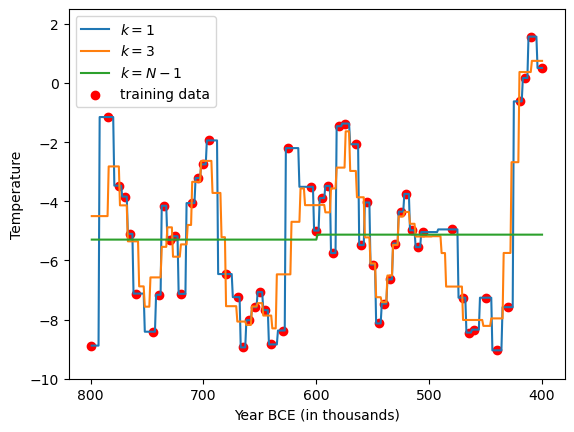

In [4]:
# plot functions
N = year_train.shape[0]
x_array = np.arange(400, 800, 1)
plt.plot(x_array, predict_knn(x_array, 1, year_train, temp_train), label = "$k = 1$")
plt.plot(x_array, predict_knn(x_array, 3, year_train, temp_train), label = "$k = 3$")
plt.plot(x_array, predict_knn(x_array, N - 1, year_train, temp_train), label = "$k = N - 1$")
plt.scatter(year_train, temp_train, label = "training data", color = "red")
plt.ylabel("Temperature")
plt.xlabel("Year BCE (in thousands)")

plt.legend()
plt.xticks(np.arange(400, 900, 100))
plt.ylim([-10,2.5])

plt.gca().invert_xaxis()
# save figure to img_output directory
plt.savefig("img_output/p1.1a.png", bbox_inches = "tight")
plt.show()

## Problem 1 Subpart 1(b)

In [5]:
def model_mse(predictions, true):
    """
    Calculate the MSE for the given model predictions, with respect to the true values

    :param predictions: predictions given by the model
    :param true: corresponding true values
    :return: the mean squared error
    """
    return np.mean((np.asarray(predictions) - np.asarray(true))**2)

In [6]:
# Compute the MSEs for different values of k
N = year_train.shape[0]
for k in [1, 3, N-1]:
    preds = predict_knn(year_test, k, year_train, temp_train)
    print(f"k = {k:<3d} test MSE = {model_mse(preds, temp_test):.4f}")

k = 1   test MSE = 1.7406
k = 3   test MSE = 3.8908
k = 56  test MSE = 9.5286


## Problem 1 Subpart 2(a)

In [7]:
def kernel_regressor(x_new, tau, x_train, y_train):
    """
    Run f_tau(x) with parameter tau on every entry of x_new.

    :param x_new: a numpy array of x_values on which to do prediction. Shape is (n,)
    :param float tau: lengthscale parameter
    :param y_train: the x coordinates of the training set
    :param y_train: the y coordinates of the training set
    :return: if x_new = [x_1, x_2, ...], then return [f(x_1), f(x_2), ...]
             where f is calculated wrt to the training data and tau
    """
    K = np.exp(-((x_new.reshape(-1,1) - x_train.reshape(1, -1))**2)/ tau)
    return (K @ y_train)/ K.sum(axis=1)

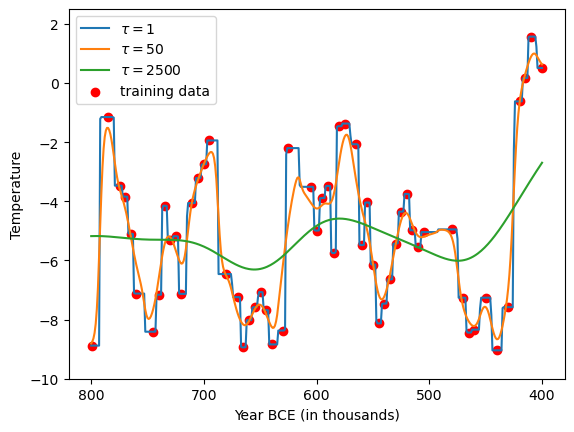

In [8]:
# Plot functions
x_array = np.arange(400, 800 + 1, 1)
for tau in [1, 50, 2500]:
    plt.plot(x_array, kernel_regressor(x_array, tau, year_train, temp_train), label = f"$\\tau = {tau}$")
plt.scatter(year_train, temp_train, label = "training data", color = "red")
plt.legend()
plt.xticks(np.arange(400, 800 + 100, 100))
plt.ylabel("Temperature")
plt.xlabel("Year BCE (in thousands)")
plt.ylim([-10,2.5])

plt.gca().invert_xaxis()
# save figure to img_output directory
plt.savefig("img_output/p1.2a.png", bbox_inches = "tight")
plt.show()

## Problem 1 Subpart 2(c)

In [9]:
# Compute the MSEs for different values of tau
for tau in [1, 50, 2500]:
    preds = kernel_regressor(year_test, tau, year_train, temp_train)
    print(f"tau = {tau:<5d} test MSE = {model_mse(preds, temp_test):.4f}")

tau = 1     test MSE = 1.9473
tau = 50    test MSE = 1.8583
tau = 2500  test MSE = 8.3339


# Problem 3

## Problem 3 Subpart 1

In [10]:
def exp_kernel(x,mu):
    return np.exp(-1/float(5)*np.power(x-mu,2))

def f_scale(X, part = "a"):
  if part == "a":
    X = X/181 # 181000
  elif part == "b":
    X = X/4e2 # 4e5
  elif part == "c":
    X = X/1.81 # 1810    
  elif part == "d":
    X = X/.181 # 181
  return X

# TODO: Complete this `make_basis` function according to the above
# specifications. The function should return the array `phi(X)`

# ------------------------------------------------- CELL: make_basis (P3.1)
# (keep exp_kernel and f_scale exactly as provided above this function)

def make_basis(X, part='a'):
    """
    Args:
      X: input of years (or any variable you want to turn into the appropriate
         basis) as ndarray with length `N`.
      part: one of `a`, `b`, `c`, `d` depending on the basis function.
    Returns:
      ndarray `phi(X)` of shape `(N,D)`. Shapes for the training data are
        (a) 57x10, (b) 57x10, (c) 57x10, (d) 57x50.
    """

    ### DO NOT CHANGE THIS SECTION
    ### it is to prevent numerical instability from taking the exponents of
    ### the years, as well as break symmetry when dealing with a Fourier basis.
    X = f_scale(X, part)
    ### end section

    X = np.asarray(X, dtype=float).reshape(-1)

    if part == 'a':
        # phi_j(x) = f(x)^j  for j = 1..9
        js = np.arange(1, 10)
        phi = X.reshape(-1, 1) ** js.reshape(1, -1)

    elif part == 'b':
        # phi_j(x) = exp(-(f(x) - mu_j)^2 / 5),  mu_j = (j+7)/8,  j = 1..9
        js = np.arange(1, 10)
        mus = (js + 7) / 8
        phi = exp_kernel(X.reshape(-1, 1), mus.reshape(1, -1))

    elif part == 'c':
        # phi_j(x) = cos(f(x) / j)  for j = 1..9
        js = np.arange(1, 10)
        phi = np.cos(X.reshape(-1, 1) / js.reshape(1, -1))

    elif part == 'd':
        # phi_j(x) = cos(f(x) / j)  for j = 1..49
        js = np.arange(1, 50)
        phi = np.cos(X.reshape(-1, 1) / js.reshape(1, -1))

    else:
        raise ValueError(f"unknown part: {part}")

    # prepend the bias column -> shape (N, D+1)
    return np.hstack([np.ones((X.shape[0], 1)), phi])

We are now solving the multi-dimensional OLS regression problem. For each $i=1,\ldots, N$, we have 
$$ \hat y_i = \mathbf{w}^\top\mathbf{\phi}(x_i) = \sum_{j=1}^D w_j \phi_j(x_i).  $$

We can find the weights that minimize the MSE $\frac 1N\| \mathbf{y} - \mathbf{\phi}(\mathbf{X})\mathbf{w}\| $ with the analytic solution described in the textbook at Derivation 2.6.1.
$$ \mathbf{w^*} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}. $$

In [11]:
# Helper function to find the regression weights using the Moore-Penrose pseudoinverse.
def find_weights(X,y):
    w_star = np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, y))
    return w_star

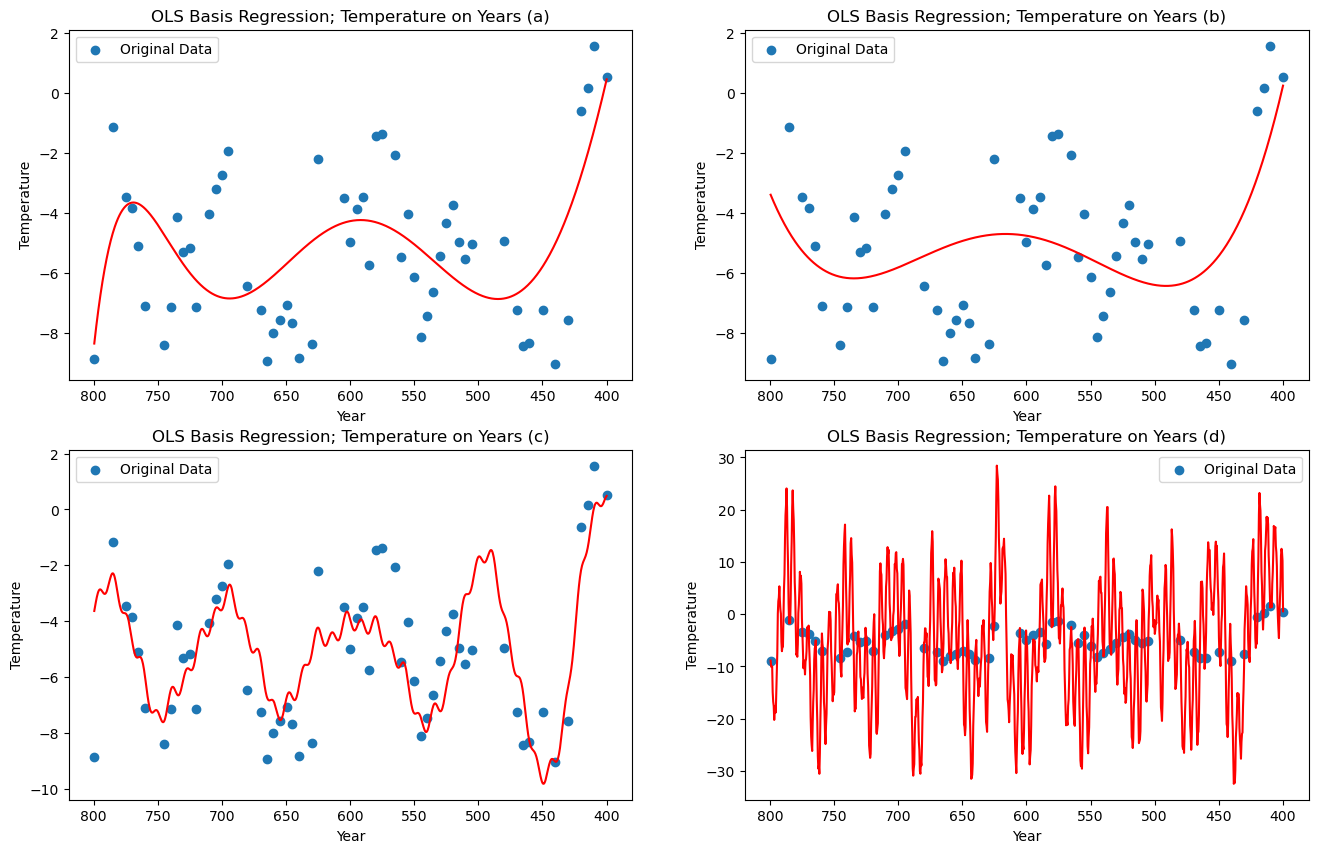

In [12]:
_, ax = plt.subplots(2,2, figsize = (16,10))

for i, part in enumerate(['a', 'b', 'c' ,'d']):
  # Plotting the original data
  phi_years_train = make_basis(year_train, part)
  w = find_weights(phi_years_train, temp_train)

  
  ax[i//2, i%2].scatter(year_train, temp_train, label = "Original Data")
  
  xs = np.linspace(year_train.min(), year_train.max(), 1000)
  ax[i//2, i%2].set_xlabel("Year")
  ax[i//2, i%2].set_ylabel("Temperature")
  ax[i//2, i%2].set_title(f"OLS Basis Regression; Temperature on Years ({part})")

  ax[i//2, i%2].legend()
  # Plot the regression line generated by the model
  ax[i//2, i%2].plot(xs, make_basis(xs, part) @ w, color="red", label="OLS fit")
  ax[i//2, i%2].invert_xaxis()
  
plt.savefig("img_output/p3.1.png")

## Problem 3 Subpart 2

In [13]:
# Compute the MSE for each basis
print(f"{'basis':<7}{'D':>4}{'train MSE':>13}{'test MSE':>12}")
for part in ['a', 'b', 'c', 'd']:
    phi_train = make_basis(year_train, part)
    w = find_weights(phi_train, temp_train)
    train_mse = model_mse(phi_train @ w, temp_train)
    test_mse = model_mse(make_basis(year_test, part) @ w, temp_test)
    print(f"({part}){'':<4}{phi_train.shape[1]:>4}{train_mse:>13.4f}{test_mse:>12.4f}")

basis     D    train MSE    test MSE
(a)      10       4.8248      7.9557
(b)      10       5.5300      8.7082
(c)      10       2.8791      5.9670
(d)      50       0.6432     58.8904


# Problem 4

## Problem 4 Subpart 5

In [14]:
def find_lasso_weights(lam, X, y, max_iter=5000):
    """
    Fit the weights of a LASSO linear regression through the coordinate
    descent algorithm.
    :param lam: the lambda parameter
    :param X: the design matrix with training set features
    :param y: the training set labels
    :return: the fitted weights
    """
    N, D = X.shape
    w = np.ones(D)                       # w_0 = vector of ones, per the spec
    sq_norms = (X ** 2).sum(axis=0)      # ||x_d||_2^2, fixed across iterations

    for _ in range(max_iter):
        w_old = w.copy()
        for d in range(D):
            # rho_d = x_d^T (y - (Xw - w_d x_d)):  the partial residual, i.e.
            # the residual with coordinate d's own contribution added back in.
            # Note w is updated in place, so later coordinates in this sweep
            # already see the newer values -- this is what "consecutively" means.
            rho = X[:, d] @ (y - (X @ w - w[d] * X[:, d]))

            if d == 0:
                # d == 1 in the problem's 1-indexed notation: the bias column,
                # which is left unpenalized (no soft-thresholding).
                w[d] = rho / sq_norms[d]
            else:
                # soft-thresholding operator
                w[d] = np.sign(rho) * max(abs(rho) - lam / 2, 0) / sq_norms[d]

        # early exit once the sweep stops changing anything
        if np.max(np.abs(w - w_old)) < 1e-12:
            break

    return w

In [15]:
# Helper function for standardizing inputs to LASSO
def preprocess_lasso(X):
    X = make_basis(X, part='d')
    X[:, 1:] = (X[:, 1:] - X[:, 1:].mean(axis = 0)) / X[:, 1:].std(axis = 0)
    return X

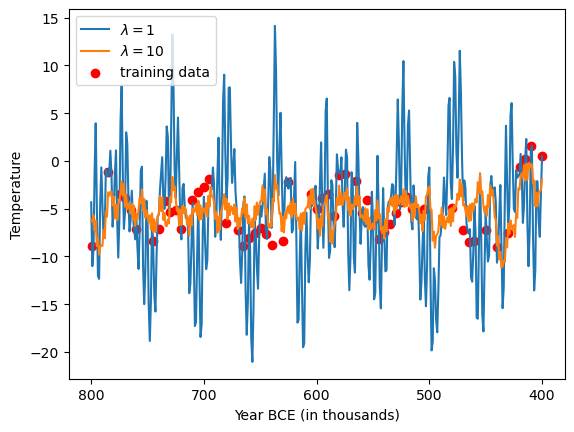

In [16]:
# Fit the weights for both models
phi_x_train = preprocess_lasso(year_train)
lam1, lam2 = 1, 10
w1 = find_lasso_weights(lam1, phi_x_train, temp_train)
w2 = find_lasso_weights(lam2, phi_x_train, temp_train)

# Plot functions
x_array = np.arange(400, 800 + 1, 1)
phi_x_array = preprocess_lasso(x_array.astype(float))

# Plot the regression line generated by the model
plt.plot(x_array, phi_x_array @ w1, label=f"$\\lambda = {lam1}$")
plt.plot(x_array, phi_x_array @ w2, label=f"$\\lambda = {lam2}$")

plt.scatter(year_train, temp_train, label = "training data", color = "red")
plt.legend()
plt.xticks(np.arange(400, 800 + 100, 100))
plt.ylabel("Temperature")
plt.xlabel("Year BCE (in thousands)")

plt.gca().invert_xaxis()
plt.savefig("img_output/p4.5.png", bbox_inches = "tight")

In [17]:
# Compute the MSE for both values of lambda
phi_x_test = preprocess_lasso(year_test)
for lam, w in [(lam1, w1), (lam2, w2)]:
    print(f"LASSO lambda = {lam:<3d} test MSE = {model_mse(phi_x_test @ w, temp_test):.4f}")

# unregularized basis (d) from Problem 3, for comparison
phi_d_train = make_basis(year_train, 'd')
w_vanilla = find_weights(phi_d_train, temp_train)
print(f"vanilla basis (d)  test MSE = "
      f"{model_mse(make_basis(year_test, 'd') @ w_vanilla, temp_test):.4f}")

# diagnostics referenced in the writeup
for name, w in [("lambda=1", w1), ("lambda=10", w2), ("vanilla", w_vanilla)]:
    print(f"{name:<10} ||w||_2 = {np.linalg.norm(w):>12.2f}   "
          f"exact zeros = {int((np.abs(w) < 1e-8).sum())}/{len(w)}")


LASSO lambda = 1   test MSE = 30.0606
LASSO lambda = 10  test MSE = 15.6184
vanilla basis (d)  test MSE = 58.8904
lambda=1   ||w||_2 =         9.36   exact zeros = 10/50
lambda=10  ||w||_2 =         5.58   exact zeros = 19/50
vanilla    ||w||_2 =    380417.27   exact zeros = 0/50
